# Notebook 2 — Transferência de Estilo Neural

Reproduzir uma fotografia com a pincelada de van Gogh ([Gatys et al., 2015](https://arxiv.org/pdf/1508.06576.pdf)).

O algoritmo usa **três imagens**: a de **conteúdo**, a de **estilo** e a **gerada** — que minimiza, ao mesmo tempo, uma distância de conteúdo $D_C$ e uma distância de estilo $D_S$.

## 0. Preparação do ambiente

Este notebook roda **localmente** e no **Google Colab**. A célula abaixo é só infraestrutura: ela garante o módulo de apoio `aula_generativa.py` (carregamento de dados, gráficos e a "cirurgia" na VGG ficam lá, fora do foco da aula). No Colab a célula aparece **recolhida** — basta executá-la e seguir em frente.


In [1]:
# >>> infra-colab-aula-generativa >>>
#@title ⚙️ Infraestrutura: módulo de apoio (execute e siga em frente) { display-mode: "form" }
import os
_APOIO = r'''

# -*- coding: utf-8 -*-
"""
Biblioteca de apoio da Aula Generativa (Encoder-Decoder, Style Transfer e GANs).

Tudo o que NÃO é o tópico central da aula (carregamento de dados, plotagem,
montagem do modelo VGG para style transfer, downloads) fica abstraído aqui,
para que os notebooks tenham apenas células pequenas e didáticas.
"""

import os
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# ----------------------------------------------------------------------
# Dispositivo e reprodutibilidade
# ----------------------------------------------------------------------

def dispositivo():
    """Retorna o melhor dispositivo disponível (MPS no Apple Silicon, CUDA ou CPU)."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def semente(seed=42):
    """Fixa a semente aleatória para reduzir a variabilidade entre execuções.

    `torch.manual_seed` já cobre CPU, CUDA e MPS, além do embaralhamento do
    DataLoader. (Em GPU, o cuDNN ainda pode introduzir pequena não-determinância.)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)


# ----------------------------------------------------------------------
# Dados
# ----------------------------------------------------------------------

_DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_data")


def carregar_mnist(batch_size=128, n_amostras=None, normalizar_11=False):
    """DataLoader do MNIST.

    normalizar_11=True deixa os pixels em [-1, 1] (necessário para a GAN,
    cujo gerador termina em Tanh). Caso contrário, pixels em [0, 1].
    """
    if normalizar_11:
        tf = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.5,), (0.5,))])
    else:
        tf = transforms.ToTensor()
    ds = datasets.MNIST(root=_DATA_DIR, train=True, download=True, transform=tf)
    if n_amostras is not None:
        ds = Subset(ds, range(n_amostras))
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


# ----------------------------------------------------------------------
# Visualização
# ----------------------------------------------------------------------

def mostrar_grade(imgs, titulo=None, n=8, desnormalizar=False):
    """Mostra um lote de imagens em grade. Aceita tensor (B, C, H, W)."""
    imgs = imgs.detach().cpu()[:n * n]
    if desnormalizar:
        imgs = imgs / 2 + 0.5
    grade = torchvision.utils.make_grid(imgs, nrow=n, padding=2)
    plt.figure(figsize=(7, 7))
    plt.imshow(np.transpose(grade.clamp(0, 1).numpy(), (1, 2, 0)))
    plt.axis("off")
    if titulo:
        plt.title(titulo)
    plt.show()


def comparar_linhas(linhas, titulos, n=8):
    """Mostra listas de imagens em linhas comparáveis (ex.: original x reconstruída)."""
    fig, axes = plt.subplots(len(linhas), n, figsize=(1.3 * n, 1.5 * len(linhas)))
    for i, (lote, titulo) in enumerate(zip(linhas, titulos)):
        lote = lote.detach().cpu()
        for j in range(n):
            ax = axes[i, j] if len(linhas) > 1 else axes[j]
            ax.imshow(lote[j].squeeze().clamp(0, 1).numpy(), cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.set_title(titulo, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()


def curva(valores, xlabel="época", ylabel="perda", titulo=None, rotulos=None):
    """Plota uma ou mais curvas de treinamento."""
    if not valores:
        return
    plt.figure(figsize=(6, 3.5))
    if isinstance(valores[0], (list, tuple, np.ndarray)):
        for serie, rot in zip(valores, rotulos or [None] * len(valores)):
            plt.plot(serie, label=rot)
        if rotulos:
            plt.legend()
    else:
        plt.plot(valores)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if titulo:
        plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def ruido(imgs, intensidade=0.5):
    """Adiciona ruído gaussiano a um lote de imagens em [0, 1]."""
    return (imgs + intensidade * torch.randn_like(imgs)).clamp(0, 1)


def interpolar_latente(decoder, z1, z2, passos=10):
    """Decodifica interpolações lineares entre dois vetores latentes.

    `decoder` pode ser o decoder do autoencoder ou o gerador G de uma GAN.
    z1, z2 têm forma (1, dim_latente) — ou (1, dim, 1, 1) para geradores
    convolucionais; o reshape de alfas se adapta à dimensionalidade de z.
    """
    alfas = torch.linspace(0, 1, passos, device=z1.device).view([-1] + [1] * (z1.dim() - 1))
    zs = (1 - alfas) * z1 + alfas * z2
    with torch.no_grad():
        return decoder(zs).cpu()


# ----------------------------------------------------------------------
# Imagens para Style Transfer
# ----------------------------------------------------------------------

_IMG_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_imagens")

_URLS_EXEMPLO = {
    "conteudo.jpg": [
        # Neckarfront de Tübingen (a foto do artigo original de Gatys) e tartaruga (Wikimedia Commons)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Tuebingen_Neckarfront.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/Green_Sea_Turtle_grazing_seagrass.jpg?width=1024",
    ],
    "estilo.jpg": [
        # A Noite Estrelada, van Gogh (domínio público)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/The_Great_Wave_off_Kanagawa.jpg?width=1024",
    ],
}


def baixar_imagens_exemplo():
    """Baixa uma imagem de conteúdo e uma de estilo (Wikimedia Commons).

    Retorna (caminho_conteudo, caminho_estilo). Se os arquivos já existem,
    não baixa de novo.
    """
    os.makedirs(_IMG_DIR, exist_ok=True)
    caminhos = []
    for nome, urls in _URLS_EXEMPLO.items():
        destino = os.path.join(_IMG_DIR, nome)
        if not os.path.exists(destino):
            for url in urls:
                try:
                    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                    with urllib.request.urlopen(req, timeout=30) as r, open(destino, "wb") as f:
                        f.write(r.read())
                    break
                except Exception as e:
                    print(f"Falha em {url[:60]}...: {e}")
        if not os.path.exists(destino):
            raise RuntimeError(
                f"Não foi possível baixar '{nome}'. Verifique a conexão ou copie "
                f"uma imagem manualmente para a pasta {_IMG_DIR}/."
            )
        caminhos.append(destino)
    return tuple(caminhos)


def carregar_imagem(caminho, tamanho=256, device=None):
    """Carrega uma imagem como tensor (1, 3, tamanho, tamanho) em [0, 1].

    Redimensiona para um quadrado `tamanho`x`tamanho`: conteúdo e estilo
    precisam ter a MESMA forma, porque os módulos de perda inseridos na VGG
    (ver `montar_modelo_estilo`) são atravessados pelas duas imagens. A leve
    distorção de proporção é aceitável para a demonstração.
    """
    tf = transforms.Compose([
        transforms.Resize((tamanho, tamanho)),
        transforms.ToTensor(),
    ])
    img = Image.open(caminho).convert("RGB")
    t = tf(img).unsqueeze(0)
    return t.to(device) if device is not None else t


def mostrar_imagens(tensores, titulos=None, figsize=(12, 5)):
    """Mostra lado a lado uma lista de tensores-imagem (1, 3, H, W)."""
    fig, axes = plt.subplots(1, len(tensores), figsize=figsize)
    if len(tensores) == 1:
        axes = [axes]
    for ax, t, titulo in zip(axes, tensores, titulos or [None] * len(tensores)):
        ax.imshow(t[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())
        ax.axis("off")
        if titulo:
            ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------------
# Montagem do modelo VGG para Style Transfer
# (a "cirurgia" na VGG fica abstraída aqui; as perdas ficam no notebook)
# ----------------------------------------------------------------------

_VGG_MEAN = torch.tensor([0.485, 0.456, 0.406])
_VGG_STD = torch.tensor([0.229, 0.224, 0.225])


class _Normalizacao(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.mean = _VGG_MEAN.view(-1, 1, 1).to(device)
        self.std = _VGG_STD.view(-1, 1, 1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std


def montar_modelo_estilo(classe_content_loss, classe_style_loss,
                         img_conteudo, img_estilo,
                         camadas_conteudo=("conv_4",),
                         camadas_estilo=("conv_1", "conv_2", "conv_3", "conv_4", "conv_5"),
                         device=None):
    """Monta a VGG-19 truncada com módulos de perda inseridos.

    Recebe as CLASSES ContentLoss e StyleLoss definidas no notebook (elas são
    o conteúdo didático) e devolve (modelo, lista_style_losses, lista_content_losses).
    """
    device = device or img_conteudo.device
    # models.vgg19() já devolve uma instância nova, então não é preciso copiar.
    cnn = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()

    modelo = nn.Sequential(_Normalizacao(device))
    perdas_estilo, perdas_conteudo = [], []

    i = 0
    for camada in cnn.children():
        if isinstance(camada, nn.Conv2d):
            i += 1
            nome = f"conv_{i}"
        elif isinstance(camada, nn.ReLU):
            nome = f"relu_{i}"
            camada = nn.ReLU(inplace=False)
        elif isinstance(camada, nn.MaxPool2d):
            nome = f"pool_{i}"
        else:
            raise RuntimeError(f"camada inesperada na VGG-19.features: {type(camada).__name__}")
        modelo.add_module(nome, camada)

        if nome in camadas_conteudo:
            alvo = modelo(img_conteudo).detach()
            perda = classe_content_loss(alvo)
            modelo.add_module(f"content_loss_{i}", perda)
            perdas_conteudo.append(perda)

        if nome in camadas_estilo:
            alvo = modelo(img_estilo).detach()
            perda = classe_style_loss(alvo)
            modelo.add_module(f"style_loss_{i}", perda)
            perdas_estilo.append(perda)

    # corta tudo que vem depois da última perda
    for j in range(len(modelo) - 1, -1, -1):
        if isinstance(modelo[j], (classe_content_loss, classe_style_loss)):
            break
    modelo = modelo[: j + 1]

    modelo.requires_grad_(False)
    return modelo, perdas_estilo, perdas_conteudo


# ----------------------------------------------------------------------
# Apoio às GANs
# ----------------------------------------------------------------------

def amostras_geradas(gerador, ruido_fixo, titulo=None):
    """Gera imagens a partir de um ruído fixo e as mostra em grade."""
    gerador.eval()
    with torch.no_grad():
        falsas = gerador(ruido_fixo).cpu()
    gerador.train()
    n = int(round(len(falsas) ** 0.5))  # grade quadrada a partir do tamanho do lote
    mostrar_grade(falsas, titulo=titulo, n=n, desnormalizar=True)


def treinar_gan(G, D, loader, epocas=3, dim_ruido=100, forma_ruido=None,
                lr=2e-4, device=None, ruido_fixo=None, mostrar_progresso=True):
    """Treina uma GAN com o MESMO loop adversarial visto no notebook.

    Útil para reaproveitar o loop com outras arquiteturas (ex.: DCGAN).
    forma_ruido: tupla extra do ruído, ex. (100, 1, 1) para geradores convolucionais.
    Retorna (perdas_D, perdas_G).

    Obs.: cada chamada cria otimizadores Adam novos (o estado/momento é zerado).
    Para *continuar* um treino, aumente `epocas` numa única chamada em vez de
    chamar a função repetidas vezes.
    """
    device = device or next(G.parameters()).device
    criterio = nn.BCELoss()
    otim_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    otim_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    forma = forma_ruido or (dim_ruido,)
    perdas_D, perdas_G = [], []

    for epoca in range(epocas):
        soma_D = soma_G = 0.0
        for reais, _ in loader:
            reais = reais.to(device)
            b = reais.size(0)
            uns = torch.ones(b, 1, device=device)
            zeros = torch.zeros(b, 1, device=device)

            # 1) treina o discriminador
            z = torch.randn(b, *forma, device=device)
            falsas = G(z)
            perda_D = criterio(D(reais).view(b, 1), uns) + \
                      criterio(D(falsas.detach()).view(b, 1), zeros)
            otim_D.zero_grad(); perda_D.backward(); otim_D.step()

            # 2) treina o gerador
            perda_G = criterio(D(falsas).view(b, 1), uns)
            otim_G.zero_grad(); perda_G.backward(); otim_G.step()

            soma_D += perda_D.item(); soma_G += perda_G.item()

        perdas_D.append(soma_D / len(loader)); perdas_G.append(soma_G / len(loader))
        print(f"época {epoca + 1}/{epocas} | perda D: {perdas_D[-1]:.3f} | perda G: {perdas_G[-1]:.3f}")
        if mostrar_progresso and ruido_fixo is not None:
            amostras_geradas(G, ruido_fixo, titulo=f"Amostras após a época {epoca + 1}")

    return perdas_D, perdas_G
'''
with open("aula_generativa.py", "w", encoding="utf-8") as _f:
    _f.write(_APOIO)
print("aula_generativa.py garantido (versão da aula).")


aula_generativa.py garantido (versão da aula).


In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
from torch import nn
import torch.nn.functional as F
try:
    import aula_generativa as ag
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "Execute primeiro a célula de infraestrutura (a primeira célula de código).")

device = ag.dispositivo()
ag.semente(42)
device

device(type='mps')

## 1. As imagens de conteúdo e de estilo

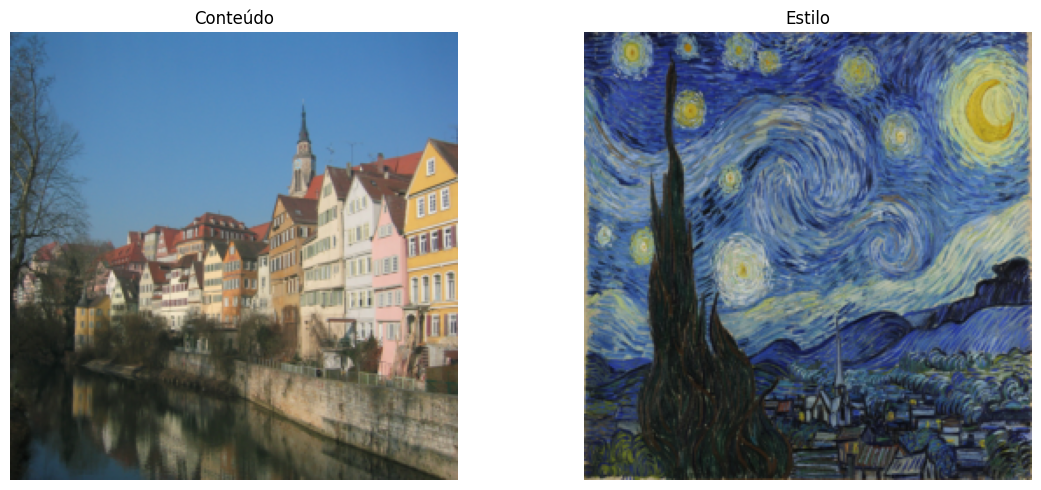

In [3]:
arq_conteudo, arq_estilo = ag.baixar_imagens_exemplo()

conteudo = ag.carregar_imagem(arq_conteudo, tamanho=256, device=device)
estilo = ag.carregar_imagem(arq_estilo, tamanho=256, device=device)
ag.mostrar_imagens([conteudo, estilo], ["Conteúdo", "Estilo"])

## 2. Perda de conteúdo

Duas imagens têm o mesmo *conteúdo* se as **features profundas** da VGG são parecidas.

O módulo abaixo guarda as features-alvo e, a cada passagem, mede o MSE — devolvendo a entrada intacta (ele apenas **observa** o fluxo).

In [4]:
class ContentLoss(nn.Module):
    def __init__(self, alvo):
        super().__init__()
        self.alvo = alvo.detach()

    def forward(self, x):
        self.loss = F.mse_loss(x, self.alvo)
        return x

## 3. Matriz de Gram: a assinatura do estilo

O estilo não depende de **onde** as coisas estão, e sim de **quais texturas aparecem juntas**. A matriz de Gram mede a correlação entre os canais de uma camada — descartando a informação espacial:

$$G = \frac{F\,F^{\top}}{b\,c\,h\,w}$$

em que $b\,c\,h\,w$ é o número total de elementos do tensor de *features*. Como aqui $b = 1$, isso equivale a $C\,h\,w$ (a forma usada nos slides), e $G \in \mathbb{R}^{C \times C}$.

In [5]:
def matriz_gram(x):
    b, c, h, w = x.size()
    feats = x.view(b * c, h * w)
    G = feats @ feats.t()
    return G / (b * c * h * w)

A perda de estilo compara as matrizes de Gram da imagem gerada e da imagem de estilo:

In [6]:
class StyleLoss(nn.Module):
    def __init__(self, alvo):
        super().__init__()
        self.alvo = matriz_gram(alvo).detach()

    def forward(self, x):
        self.loss = F.mse_loss(matriz_gram(x), self.alvo)
        return x

## 4. A VGG-19 congelada, com as perdas inseridas

A VGG-19 pré-treinada na ImageNet funciona apenas como **instrumento de medida** — ela nunca é treinada aqui.

A função da biblioteca insere `ContentLoss` depois de `conv_4` e `StyleLoss` depois de `conv_1 … conv_5`, exatamente como no artigo original.

In [7]:
modelo, perdas_estilo, perdas_conteudo = ag.montar_modelo_estilo(
    ContentLoss, StyleLoss, conteudo, estilo,
    camadas_conteudo=("conv_4",),
    camadas_estilo=("conv_1", "conv_2", "conv_3", "conv_4", "conv_5"),
    device=device)

print(f"{len(perdas_conteudo)} perda(s) de conteúdo | {len(perdas_estilo)} perdas de estilo")

1 perda(s) de conteúdo | 5 perdas de estilo


## 5. Otimizar a imagem, não a rede

A grande inversão deste algoritmo: os pesos da rede ficam **congelados** e o gradiente desce sobre **os pixels da imagem gerada**.

> Usamos o **Adam** por simplicidade; o artigo original de Gatys usa o otimizador L-BFGS.

In [8]:
imagem = conteudo.clone().requires_grad_(True)
otimizador = torch.optim.Adam([imagem], lr=0.02)

PESO_ESTILO, PESO_CONTEUDO = 1e6, 1.0

In [9]:
for passo in range(301):
    otimizador.zero_grad()
    modelo(imagem)                     # as perdas se atualizam na passagem

    perda_e = sum(p.loss for p in perdas_estilo) * PESO_ESTILO
    perda_c = sum(p.loss for p in perdas_conteudo) * PESO_CONTEUDO
    (perda_e + perda_c).backward()

    otimizador.step()
    with torch.no_grad():
        imagem.clamp_(0, 1)

    if passo % 100 == 0:
        print(f"passo {passo:3d} | estilo: {perda_e.item():9.2f} | conteúdo: {perda_c.item():7.2f}")

passo   0 | estilo:   6955.47 | conteúdo:    0.00


passo 100 | estilo:     17.93 | conteúdo:   18.18


passo 200 | estilo:      9.14 | conteúdo:   15.96


passo 300 | estilo:      7.31 | conteúdo:   14.59


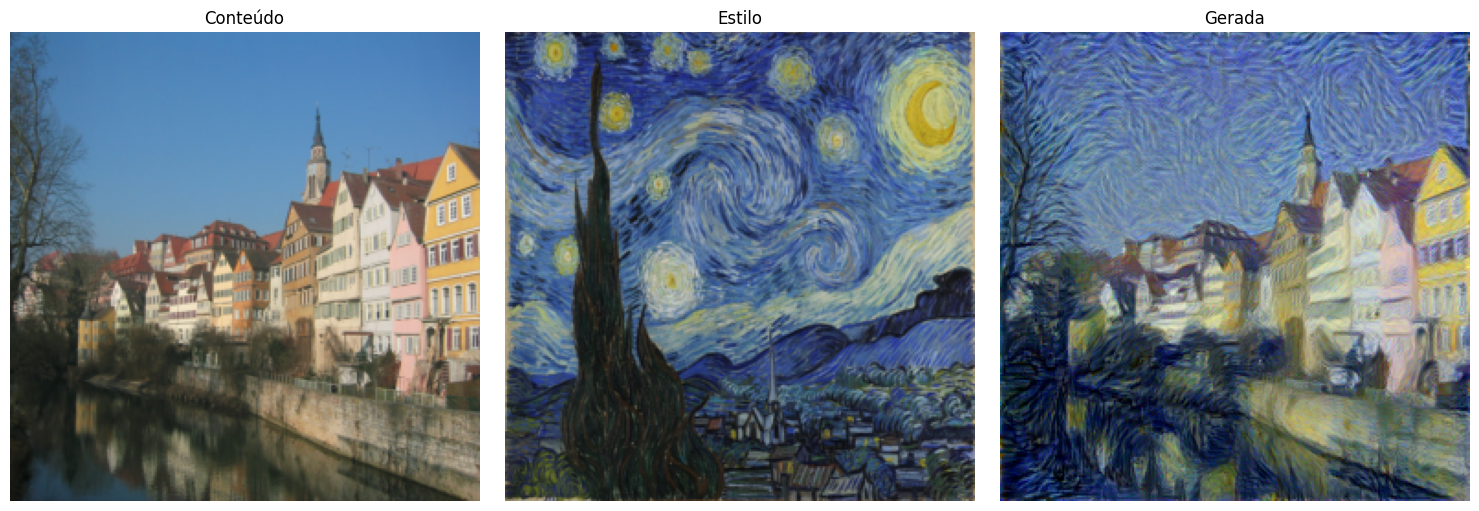

In [10]:
ag.mostrar_imagens([conteudo, estilo, imagem],
                   ["Conteúdo", "Estilo", "Gerada"], figsize=(15, 5))

## Exercícios

In [11]:
# TODO Exercício 1: altere PESO_ESTILO na célula da seção 5 (1e7 e depois 1e4),
# reinicie a imagem (reexecute as células de otimização) e compare. Como o
# equilíbrio conteúdo x estilo muda o resultado?

In [12]:
# TODO Exercício 2: use uma foto sua como conteúdo. Basta copiar o arquivo
# para a pasta _imagens/ e carregá-lo com ag.carregar_imagem("_imagens/minha_foto.jpg").
# Dica: imagens com formas bem definidas funcionam melhor.

## Resumo e próximos passos

- A transferência de estilo usa uma CNN **congelada** como instrumento de medida.
- **Conteúdo** = features profundas; **estilo** = correlações (matriz de Gram) em várias camadas.
- Otimizamos **a imagem**, não a rede — gradiente descendente sobre pixels.
- O balanço $\alpha\,D_C + \beta\,D_S$ controla o resultado.
- No Notebook 3 invertemos de novo o jogo: em vez de otimizar uma imagem, treinamos uma rede que **gera imagens do zero** — as GANs.